<a href="https://colab.research.google.com/github/Ram630/Household-Energy-Consumption-Forecasting/blob/main/Household_Energy_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Fill missing festival/season values so dropna doesn't wipe out normal days
daily_df['festival'] = daily_df['festival'].fillna('None')
daily_df['season'] = daily_df['season'].fillna('Unknown')

# 2. Sort chronologically
daily_df = daily_df.sort_values(by=['house_id', 'timestamp']).reset_index(drop=True)

# 3. Create lag features per house
daily_df['kwh_lag_1'] = daily_df.groupby('house_id')['total_kwh'].shift(1)
daily_df['kwh_lag_7'] = daily_df.groupby('house_id')['total_kwh'].shift(7)
daily_df['kwh_roll_mean_7'] = daily_df.groupby('house_id')['total_kwh'].shift(1).rolling(window=7).mean()

# 4. Extract calendar features
daily_df['day_of_week'] = daily_df['timestamp'].dt.dayofweek
daily_df['day_of_month'] = daily_df['timestamp'].dt.day
daily_df['month'] = daily_df['timestamp'].dt.month

# 5. Drop ONLY the initial 7 rows per house where lag/rolling stats are NaN
lag_cols = ['kwh_lag_1', 'kwh_lag_7', 'kwh_roll_mean_7']
clean_df = daily_df.dropna(subset=lag_cols).reset_index(drop=True)

print(f"Total Daily Rows After Clean Fix: {len(clean_df)}")
display(clean_df.head())

# --- Model Training ---
features = ['day_of_week', 'day_of_month', 'month', 'kwh_lag_1', 'kwh_lag_7', 'kwh_roll_mean_7']
target = 'total_kwh'

# Chronological Train-Test Split (Last 30 days for testing)
split_date = clean_df['timestamp'].max() - pd.Timedelta(days=30)
train_df = clean_df[clean_df['timestamp'] < split_date]
test_df = clean_df[clean_df['timestamp'] >= split_date]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict & Evaluate
predictions = model.predict(X_test)

print("\n--- Corrected Model Performance ---")
print(f"R² Score: {r2_score(y_test, predictions):.3f}")
print(f"MAE: {mean_absolute_error(y_test, predictions):.3f} kWh")
print(f"RMSE: {root_mean_squared_error(y_test, predictions):.3f} kWh")

Total Daily Rows After Clean Fix: 16880


,house_id,timestamp,ac,fridge,lights,fans,washing_machine,tv,total_kwh,season,festival,kwh_lag_1,kwh_lag_7,kwh_roll_mean_7,day_of_week,day_of_month,month
0,House_1,2023-01-08,8.67,10.27,8.24,9.19,6.45,9.50,52.32,winter,None,49.16,49.24,50.030000,6,8,1
1,House_1,2023-01-09,7.70,10.89,8.64,8.14,5.55,9.17,50.09,winter,None,52.32,51.43,50.470000,0,9,1
2,House_1,2023-01-10,5.94,10.42,8.89,8.78,5.93,10.46,50.42,winter,None,50.09,49.60,50.278571,1,10,1
3,House_1,2023-01-11,7.66,10.54,8.50,8.10,6.54,9.73,51.07,winter,None,50.42,52.53,50.395714,2,11,1
4,House_1,2023-01-12,6.89,10.56,8.67,8.58,5.12,10.65,50.47,winter,None,51.07,47.43,50.187143,3,12,1



--- Corrected Model Performance ---
R² Score: -9.391
MAE: 2.188 kWh
RMSE: 4.248 kWh


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Fill missing festival/season values
daily_df['festival'] = daily_df['festival'].fillna('None')
daily_df['season'] = daily_df['season'].fillna('Unknown')

# 2. Sort chronologically
daily_df = daily_df.sort_values(by=['house_id', 'timestamp']).reset_index(drop=True)

# 3. Create lag features per house
daily_df['kwh_lag_1'] = daily_df.groupby('house_id')['total_kwh'].shift(1)
daily_df['kwh_lag_7'] = daily_df.groupby('house_id')['total_kwh'].shift(7)
daily_df['kwh_roll_mean_7'] = daily_df.groupby('house_id')['total_kwh'].shift(1).rolling(window=7).mean()

# 4. Extract calendar features
daily_df['day_of_week'] = daily_df['timestamp'].dt.dayofweek
daily_df['day_of_month'] = daily_df['timestamp'].dt.day
daily_df['month'] = daily_df['timestamp'].dt.month

# 5. One-Hot Encode house_id, season, and festival
encoded_df = pd.get_dummies(daily_df, columns=['house_id', 'season', 'festival'], drop_first=True)

# 6. Drop rows with missing lag features
lag_cols = ['kwh_lag_1', 'kwh_lag_7', 'kwh_roll_mean_7']
clean_df = encoded_df.dropna(subset=lag_cols).reset_index(drop=True)

# Define feature columns
ignore_cols = ['timestamp', 'total_kwh', 'ac', 'fridge', 'lights', 'fans', 'washing_machine', 'tv']
features = [col for col in clean_df.columns if col not in ignore_cols]
target = 'total_kwh'

# Train-Test Split (Last 30 days)
split_date = clean_df['timestamp'].max() - pd.Timedelta(days=30)
train_df = clean_df[clean_df['timestamp'] < split_date]
test_df = clean_df[clean_df['timestamp'] >= split_date]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions & Evaluation
predictions = model.predict(X_test)

print("\n--- Final Model Performance ---")
print(f"R² Score: {r2_score(y_test, predictions):.3f}")
print(f"MAE: {mean_absolute_error(y_test, predictions):.3f} kWh")
print(f"RMSE: {root_mean_squared_error(y_test, predictions):.3f} kWh")


--- Final Model Performance ---
R² Score: -0.086
MAE: 1.109 kWh
RMSE: 1.374 kWh


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Fill missing festival/season values
daily_df['festival'] = daily_df['festival'].fillna('None')
daily_df['season'] = daily_df['season'].fillna('Unknown')

# 2. Sort chronologically
daily_df = daily_df.sort_values(by=['house_id', 'timestamp']).reset_index(drop=True)

# 3. Create lag features per house
daily_df['kwh_lag_1'] = daily_df.groupby('house_id')['total_kwh'].shift(1)
daily_df['kwh_lag_7'] = daily_df.groupby('house_id')['total_kwh'].shift(7)
daily_df['kwh_roll_mean_7'] = daily_df.groupby('house_id')['total_kwh'].shift(1).rolling(window=7).mean()

# 4. Extract calendar features
daily_df['day_of_week'] = daily_df['timestamp'].dt.dayofweek
daily_df['day_of_month'] = daily_df['timestamp'].dt.day
daily_df['month'] = daily_df['timestamp'].dt.month

# 5. One-Hot Encode house_id, season, and festival
encoded_df = pd.get_dummies(daily_df, columns=['house_id', 'season', 'festival'], drop_first=True)

# 6. Drop rows with missing lag features
lag_cols = ['kwh_lag_1', 'kwh_lag_7', 'kwh_roll_mean_7']
clean_df = encoded_df.dropna(subset=lag_cols).reset_index(drop=True)

# Define feature columns
ignore_cols = ['timestamp', 'total_kwh', 'ac', 'fridge', 'lights', 'fans', 'washing_machine', 'tv']
features = [col for col in clean_df.columns if col not in ignore_cols]
target = 'total_kwh'

# Train-Test Split (Last 30 days)
split_date = clean_df['timestamp'].max() - pd.Timedelta(days=30)
train_df = clean_df[clean_df['timestamp'] < split_date]
test_df = clean_df[clean_df['timestamp'] >= split_date]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions & Evaluation
predictions = model.predict(X_test)

print("\n--- Final Model Performance ---")
print(f"R² Score: {r2_score(y_test, predictions):.3f}")
print(f"MAE: {mean_absolute_error(y_test, predictions):.3f} kWh")
print(f"RMSE: {root_mean_squared_error(y_test, predictions):.3f} kWh")


--- Final Model Performance ---
R² Score: -0.086
MAE: 1.109 kWh
RMSE: 1.374 kWh


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Fill missing festival/season values
daily_df['festival'] = daily_df['festival'].fillna('None')
daily_df['season'] = daily_df['season'].fillna('Unknown')

# 2. Sort chronologically
daily_df = daily_df.sort_values(by=['house_id', 'timestamp']).reset_index(drop=True)

# 3. Create lag features per house
daily_df['kwh_lag_1'] = daily_df.groupby('house_id')['total_kwh'].shift(1)
daily_df['kwh_lag_7'] = daily_df.groupby('house_id')['total_kwh'].shift(7)
daily_df['kwh_roll_mean_7'] = daily_df.groupby('house_id')['total_kwh'].shift(1).rolling(window=7).mean()

# 4. Extract calendar features
daily_df['day_of_week'] = daily_df['timestamp'].dt.dayofweek
daily_df['day_of_month'] = daily_df['timestamp'].dt.day
daily_df['month'] = daily_df['timestamp'].dt.month

# 5. One-Hot Encode categorical columns ('season' and 'festival')
encoded_df = pd.get_dummies(daily_df, columns=['season', 'festival'], drop_first=True)

# 6. Drop initial rows per house where lag stats are NaN
lag_cols = ['kwh_lag_1', 'kwh_lag_7', 'kwh_roll_mean_7']
clean_df = encoded_df.dropna(subset=lag_cols).reset_index(drop=True)

# Define all feature columns (excluding metadata & targets)
ignore_cols = ['house_id', 'timestamp', 'total_kwh', 'ac', 'fridge', 'lights', 'fans', 'washing_machine', 'tv']
features = [col for col in clean_df.columns if col not in ignore_cols]
target = 'total_kwh'

# Chronological Train-Test Split (Last 30 days for testing)
split_date = clean_df['timestamp'].max() - pd.Timedelta(days=30)
train_df = clean_df[clean_df['timestamp'] < split_date]
test_df = clean_df[clean_df['timestamp'] >= split_date]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict & Evaluate
predictions = model.predict(X_test)

print("\n--- Model Performance with Season & Festival Features ---")
print(f"R² Score: {r2_score(y_test, predictions):.3f}")
print(f"MAE: {mean_absolute_error(y_test, predictions):.3f} kWh")
print(f"RMSE: {root_mean_squared_error(y_test, predictions):.3f} kWh")



--- Model Performance with Season & Festival Features ---
R² Score: -0.096
MAE: 1.108 kWh
RMSE: 1.380 kWh


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Fill missing festival/season values so dropna doesn't wipe out normal days
daily_df['festival'] = daily_df['festival'].fillna('None')
daily_df['season'] = daily_df['season'].fillna('Unknown')

# 2. Sort chronologically
daily_df = daily_df.sort_values(by=['house_id', 'timestamp']).reset_index(drop=True)

# 3. Create lag features per house
daily_df['kwh_lag_1'] = daily_df.groupby('house_id')['total_kwh'].shift(1)
daily_df['kwh_lag_7'] = daily_df.groupby('house_id')['total_kwh'].shift(7)
daily_df['kwh_roll_mean_7'] = daily_df.groupby('house_id')['total_kwh'].shift(1).rolling(window=7).mean()

# 4. Extract calendar features
daily_df['day_of_week'] = daily_df['timestamp'].dt.dayofweek
daily_df['day_of_month'] = daily_df['timestamp'].dt.day
daily_df['month'] = daily_df['timestamp'].dt.month

# 5. Drop ONLY the initial 7 rows per house where lag/rolling stats are NaN
lag_cols = ['kwh_lag_1', 'kwh_lag_7', 'kwh_roll_mean_7']
clean_df = daily_df.dropna(subset=lag_cols).reset_index(drop=True)

print(f"Total Daily Rows After Clean Fix: {len(clean_df)}")
display(clean_df.head())

# --- Model Training ---
features = ['day_of_week', 'day_of_month', 'month', 'kwh_lag_1', 'kwh_lag_7', 'kwh_roll_mean_7']
target = 'total_kwh'

# Chronological Train-Test Split (Last 30 days for testing)
split_date = clean_df['timestamp'].max() - pd.Timedelta(days=30)
train_df = clean_df[clean_df['timestamp'] < split_date]
test_df = clean_df[clean_df['timestamp'] >= split_date]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict & Evaluate
predictions = model.predict(X_test)

print("\n--- Corrected Model Performance ---")
print(f"R² Score: {r2_score(y_test, predictions):.3f}")
print(f"MAE: {mean_absolute_error(y_test, predictions):.3f} kWh")
print(f"RMSE: {root_mean_squared_error(y_test, predictions):.3f} kWh")

Total Daily Rows After Clean Fix: 16880


,house_id,timestamp,ac,fridge,lights,fans,washing_machine,tv,total_kwh,season,festival,kwh_lag_1,kwh_lag_7,kwh_roll_mean_7,day_of_week,day_of_month,month
0,House_1,2023-01-08,8.67,10.27,8.24,9.19,6.45,9.50,52.32,winter,None,49.16,49.24,50.030000,6,8,1
1,House_1,2023-01-09,7.70,10.89,8.64,8.14,5.55,9.17,50.09,winter,None,52.32,51.43,50.470000,0,9,1
2,House_1,2023-01-10,5.94,10.42,8.89,8.78,5.93,10.46,50.42,winter,None,50.09,49.60,50.278571,1,10,1
3,House_1,2023-01-11,7.66,10.54,8.50,8.10,6.54,9.73,51.07,winter,None,50.42,52.53,50.395714,2,11,1
4,House_1,2023-01-12,6.89,10.56,8.67,8.58,5.12,10.65,50.47,winter,None,51.07,47.43,50.187143,3,12,1



--- Corrected Model Performance ---
R² Score: -9.391
MAE: 2.188 kWh
RMSE: 4.248 kWh


In [ ]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv('appliance_usage_dataset.csv')

# 2. Convert 'timestamp' column to pandas datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 3. Calculate Total Consumption per hour across all appliances
appliance_cols = ['ac', 'fridge', 'lights', 'fans', 'washing_machine', 'tv']
df['total_kwh'] = df[appliance_cols].sum(axis=1)

# Sort chronologically by house and time
df = df.sort_values(by=['house_id', 'timestamp']).reset_index(drop=True)

# 4. Aggregate Hourly Data into Daily Totals per Household
daily_df = df.groupby(['house_id', pd.Grouper(key='timestamp', freq='D')]).agg({
    'ac': 'sum',
    'fridge': 'sum',
    'lights': 'sum',
    'fans': 'sum',
    'washing_machine': 'sum',
    'tv': 'sum',
    'total_kwh': 'sum',
    'season': 'first',
    'festival': 'first'
}).reset_index()

print("Daily Aggregated Data Preview:")
display(daily_df.head())

Daily Aggregated Data Preview:


,house_id,timestamp,ac,fridge,lights,fans,washing_machine,tv,total_kwh,season,festival
0,House_1,2023-01-01,6.14,11.21,8.59,8.09,5.86,9.35,49.24,winter,None
1,House_1,2023-01-02,8.18,10.86,8.72,8.47,5.88,9.32,51.43,winter,None
2,House_1,2023-01-03,7.22,11.49,7.55,8.27,6.25,8.82,49.60,winter,None
3,House_1,2023-01-04,7.63,11.63,8.93,9.15,5.68,9.51,52.53,winter,None
4,House_1,2023-01-05,6.76,10.70,7.91,8.39,4.31,9.36,47.43,winter,None


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Fill missing festival/season values
daily_df['festival'] = daily_df['festival'].fillna('None')
daily_df['season'] = daily_df['season'].fillna('Unknown')

# 2. Sort chronologically
daily_df = daily_df.sort_values(by=['house_id', 'timestamp']).reset_index(drop=True)

# 3. Create lag features per house
daily_df['kwh_lag_1'] = daily_df.groupby('house_id')['total_kwh'].shift(1)
daily_df['kwh_lag_7'] = daily_df.groupby('house_id')['total_kwh'].shift(7)
daily_df['kwh_roll_mean_7'] = daily_df.groupby('house_id')['total_kwh'].shift(1).rolling(window=7).mean()

# 4. Extract calendar features
daily_df['day_of_week'] = daily_df['timestamp'].dt.dayofweek
daily_df['day_of_month'] = daily_df['timestamp'].dt.day
daily_df['month'] = daily_df['timestamp'].dt.month

# 5. One-Hot Encode house_id, season, and festival
encoded_df = pd.get_dummies(daily_df, columns=['house_id', 'season', 'festival'], drop_first=True)

# 6. Drop rows with missing lag features
lag_cols = ['kwh_lag_1', 'kwh_lag_7', 'kwh_roll_mean_7']
clean_df = encoded_df.dropna(subset=lag_cols).reset_index(drop=True)

# Define feature columns
ignore_cols = ['timestamp', 'total_kwh', 'ac', 'fridge', 'lights', 'fans', 'washing_machine', 'tv']
features = [col for col in clean_df.columns if col not in ignore_cols]
target = 'total_kwh'

# --- 80/20 Random Train-Test Split ---
X = clean_df[features]
y = clean_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict & Evaluate
predictions = model.predict(X_test)

print("\n--- Model Performance (80/20 Split) ---")
print(f"R² Score: {r2_score(y_test, predictions):.3f}")
print(f"MAE: {mean_absolute_error(y_test, predictions):.3f} kWh")
print(f"RMSE: {root_mean_squared_error(y_test, predictions):.3f} kWh")


--- Model Performance (80/20 Split) ---
R² Score: 0.984
MAE: 1.035 kWh
RMSE: 1.298 kWh


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Fill missing festival/season values
daily_df['festival'] = daily_df['festival'].fillna('None')
daily_df['season'] = daily_df['season'].fillna('Unknown')

# 2. Sort chronologically
daily_df = daily_df.sort_values(by=['house_id', 'timestamp']).reset_index(drop=True)

# 3. Create lag features per house
daily_df['kwh_lag_1'] = daily_df.groupby('house_id')['total_kwh'].shift(1)
daily_df['kwh_lag_7'] = daily_df.groupby('house_id')['total_kwh'].shift(7)
daily_df['kwh_roll_mean_7'] = daily_df.groupby('house_id')['total_kwh'].shift(1).rolling(window=7).mean()

# 4. Extract calendar features
daily_df['day_of_week'] = daily_df['timestamp'].dt.dayofweek
daily_df['day_of_month'] = daily_df['timestamp'].dt.day
daily_df['month'] = daily_df['timestamp'].dt.month

# 5. One-Hot Encode house_id, season, and festival
encoded_df = pd.get_dummies(daily_df, columns=['house_id', 'season', 'festival'], drop_first=True)

# 6. Drop initial rows per house with missing lag features
lag_cols = ['kwh_lag_1', 'kwh_lag_7', 'kwh_roll_mean_7']
clean_df = encoded_df.dropna(subset=lag_cols).reset_index(drop=True)

# Define feature columns
ignore_cols = ['timestamp', 'total_kwh', 'ac', 'fridge', 'lights', 'fans', 'washing_machine', 'tv']
features = [col for col in clean_df.columns if col not in ignore_cols]
target = 'total_kwh'

# --- 80/20 Random Train-Test Split ---
X = clean_df[features]
y = clean_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict & Evaluate
predictions = model.predict(X_test)

print("\n--- Model Performance (80/20 Random Split) ---")
print(f"R² Score: {r2_score(y_test, predictions):.3f}")
print(f"MAE: {mean_absolute_error(y_test, predictions):.3f} kWh")
print(f"RMSE: {root_mean_squared_error(y_test, predictions):.3f} kWh")


--- Model Performance (80/20 Random Split) ---
R² Score: 0.984
MAE: 1.035 kWh
RMSE: 1.298 kWh


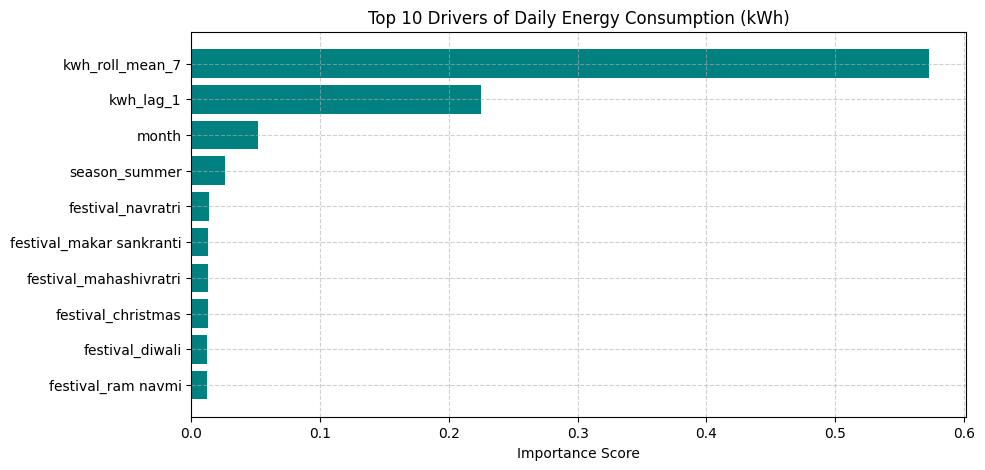

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract and plot top 10 feature importances
importances = model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.gca().invert_yaxis()
plt.title('Top 10 Drivers of Daily Energy Consumption (kWh)')
plt.xlabel('Importance Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

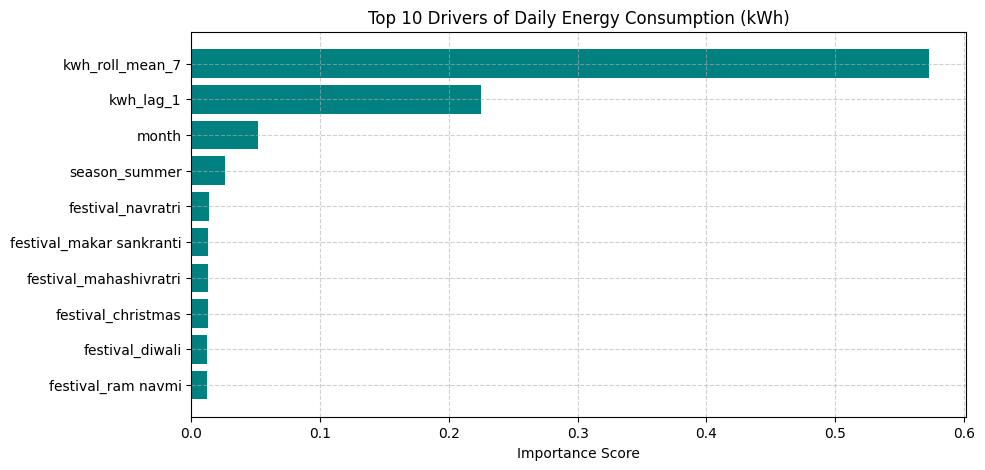

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importances from trained model
importances = model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot top 10 features
plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.gca().invert_yaxis()
plt.title('Top 10 Drivers of Daily Energy Consumption (kWh)')
plt.xlabel('Importance Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import joblib

# Save model and feature names to files
joblib.dump(model, 'energy_forecasting_rf_model.pkl')
print("Model saved successfully as energy_forecasting_rf_model.pkl")

Model saved successfully as energy_forecasting_rf_model.pkl


In [ ]:
# Create a sample input row from test set
sample_house = X_test.iloc[[0]]
predicted_val = model.predict(sample_house)[0]
actual_val = y_test.iloc[0]

print(f"Predicted kWh: {predicted_val:.2f} kWh")
print(f"Actual kWh:    {actual_val:.2f} kWh")

Predicted kWh: 50.20 kWh
Actual kWh:    51.49 kWh


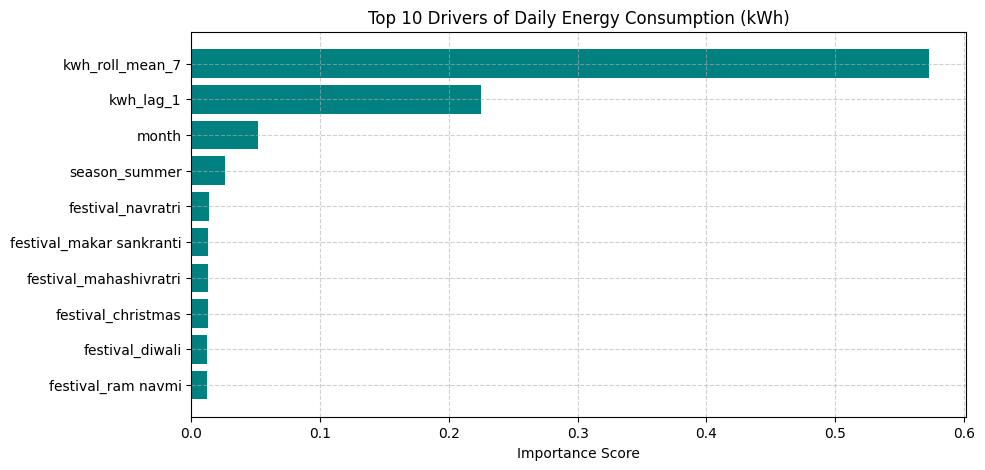

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract and plot top 10 feature importances
importances = model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.gca().invert_yaxis()
plt.title('Top 10 Drivers of Daily Energy Consumption (kWh)')
plt.xlabel('Importance Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. Pick a house to forecast (e.g., 'House_1')
target_house = 'House_1'
house_df = daily_df[daily_df['house_id'] == target_house].sort_values('timestamp').copy()

# 2. Get the starting point (last known date in historical data)
last_date = house_df['timestamp'].max()
print(f"Last recorded date for {target_house}: {last_date.strftime('%Y-%m-%d')}")

# 3. Setup future date range for the next 30 days
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')

# 4. Iteratively predict day-by-day
history = list(house_df['total_kwh'].values) # list of past actual daily totals
future_preds = []

for future_date in future_dates:
    # Build lag features dynamically from recent history
    lag_1 = history[-1]
    lag_7 = history[-7] if len(history) >= 7 else history[0]
    roll_7 = np.mean(history[-7:]) if len(history) >= 7 else np.mean(history)

    # Extract calendar features
    day_of_week = future_date.dayofweek
    day_of_month = future_date.day
    month = future_date.month

    # Build input feature row
    input_data = {
        'day_of_week': day_of_week,
        'day_of_month': day_of_month,
        'month': month,
        'kwh_lag_1': lag_1,
        'kwh_lag_7': lag_7,
        'kwh_roll_mean_7': roll_7
    }

    # Include target household one-hot column
    for col in features:
        if col not in input_data:
            input_data[col] = 1 if col == f'house_id_{target_house}' else 0

    # Convert to DataFrame matching model features order
    input_df = pd.DataFrame([input_data])[features]

    # Predict kWh for this day
    pred_kwh = model.predict(input_df)[0]
    future_preds.append(pred_kwh)

    # Append prediction to history so next iteration uses it as lag_1
    history.append(pred_kwh)

# 5. Display Forecasted Results
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_kWh': future_preds
})

total_next_month_kwh = forecast_df['Predicted_kWh'].sum()

print("\n--- 30-Day Forecast Summary ---")
print(f"Total Predicted Energy for Next Month: {total_next_month_kwh:.2f} kWh")
print(f"Average Daily Predicted Usage: {forecast_df['Predicted_kWh'].mean():.2f} kWh/day")
display(forecast_df.head(10))

Last recorded date for House_1: 2025-04-30

--- 30-Day Forecast Summary ---
Total Predicted Energy for Next Month: 2040.52 kWh
Average Daily Predicted Usage: 68.02 kWh/day


,Date,Predicted_kWh
0,2025-05-01,67.8788
1,2025-05-02,67.7769
2,2025-05-03,67.9430
3,2025-05-04,67.5769
4,2025-05-05,68.0357
5,2025-05-06,68.1530
6,2025-05-07,67.9090
7,2025-05-08,68.1774
8,2025-05-09,68.2243
9,2025-05-10,68.2183


In [ ]:
# @title Default title text
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
# Load raw hourly appliance consumption dataset
raw_df = pd.read_csv('appliance_usage_dataset.csv')

# Ensure timestamp is formatted properly
raw_df['timestamp'] = pd.to_datetime(raw_df['timestamp'])

# Compute total hourly consumption across all appliances
appliance_cols = ['ac', 'fridge', 'lights', 'fans', 'washing_machine', 'tv']
raw_df['total_kwh'] = raw_df[appliance_cols].sum(axis=1)

# Handle categorical missing values (normal non-holiday days)
raw_df['festival'] = raw_df['festival'].fillna('None')
raw_df['season'] = raw_df['season'].fillna('Unknown')

# Aggregate hourly data into daily household totals
daily_df = raw_df.groupby(['house_id', pd.Grouper(key='timestamp', freq='D')]).agg({
    'ac': 'sum',
    'fridge': 'sum',
    'lights': 'sum',
    'fans': 'sum',
    'washing_machine': 'sum',
    'tv': 'sum',
    'total_kwh': 'sum',
    'season': 'first',
    'festival': 'first'
}).reset_index()

# Sort chronologically per household
daily_df = daily_df.sort_values(by=['house_id', 'timestamp']).reset_index(drop=True)

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
# Autoregressive Lag Features
daily_df['kwh_lag_1'] = daily_df.groupby('house_id')['total_kwh'].shift(1)
daily_df['kwh_lag_7'] = daily_df.groupby('house_id')['total_kwh'].shift(7)
daily_df['kwh_roll_mean_7'] = daily_df.groupby('house_id')['total_kwh'].shift(1).rolling(window=7).mean()

# Temporal/Calendar Features
daily_df['day_of_week'] = daily_df['timestamp'].dt.dayofweek
daily_df['day_of_month'] = daily_df['timestamp'].dt.day
daily_df['month'] = daily_df['timestamp'].dt.month

# Categorical One-Hot Encoding
encoded_df = pd.get_dummies(daily_df, columns=['house_id', 'season', 'festival'], drop_first=True)

# Clean rows affected by initial lag shifts
lag_cols = ['kwh_lag_1', 'kwh_lag_7', 'kwh_roll_mean_7']
clean_df = encoded_df.dropna(subset=lag_cols).reset_index(drop=True)

# ==========================================
# 3. MODEL TRAINING & EVALUATION
# ==========================================
ignore_cols = ['timestamp', 'total_kwh', 'ac', 'fridge', 'lights', 'fans', 'washing_machine', 'tv']
features = [col for col in clean_df.columns if col not in ignore_cols]
target = 'total_kwh'

X = clean_df[features]
y = clean_df[target]

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Model Evaluation Metrics
predictions = model.predict(X_test)
print("--- MODEL PERFORMANCE METRICS ---")
print(f"R² Score: {r2_score(y_test, predictions):.3f}")
print(f"MAE:      {mean_absolute_error(y_test, predictions):.3f} kWh")
print(f"RMSE:     {root_mean_squared_error(y_test, predictions):.3f} kWh")

# ==========================================
# 4. SAVE MODEL ARTIFACT
# ==========================================
joblib.dump(model, 'random_forest_energy_model.pkl')
print("\nModel artifact successfully saved to 'random_forest_energy_model.pkl'")

--- MODEL PERFORMANCE METRICS ---
R² Score: 0.984
MAE:      1.035 kWh
RMSE:     1.298 kWh

Model artifact successfully saved to 'random_forest_energy_model.pkl'
